# Simplified Attention Without Trainable Weights

- This is the final code that will generate context vectors from input embedding vectors for all six words "dream big anf work for it'
- The attention mechanism is a simple dot product + softmax normalization
No trainable weights are used
- Visualizations where appropriate

In [1]:
import torch
import torch.nn.functional as F

## Input Vectors

In [2]:
# Words
words = ['Dream', 'big', 'and', 'work', 'for', 'it']

# Input Vectors corresponding to the words
inputs = torch.tensor(
    [[0.72, 0.45, 0.31], # dream
     [0.75,0.20,0.55],   # big
     [0.30,0.80,0.40],   # and
     [0.85,0.35,0.60],   # work
     [0.55,0.15,0.75],   # for
     [0.25,0.20,0.85]]   # it
)

## Magnitude of Input Vectors

In [3]:
# Calculate the magnitude of each vector
magnitudes = torch.norm(inputs, dim =1)

# Print the magnitudes
print("Magnitudes of the vectors:")
for word, magnitude in zip(words, magnitudes):
    print(f"{word}: {magnitude.item():.4f}")
    

Magnitudes of the vectors:
Dream: 0.9039
big: 0.9513
and: 0.9434
work: 1.0977
for: 0.9421
it: 0.9083


## Plot the 3D Input Vectors

In [4]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def plot_3d_vectors(inputs, words, colors, widths):
    fig = plt.figure(figsize=(7,7))
    ax = fig.add_subplot(111, projection='3d')

    x_coords = inputs[:,0].numpy()
    y_coords = inputs[:,1].numpy()
    z_coords = inputs[:,2].numpy()

    for x, y, z, word, color, lw in zip(x_coords, y_coords, z_coords, words, colors,widths):
        ax.quiver(0, 0, 0, x, y, z, color=color, arrow_length_ratio=0.05, linewidth =lw)
        ax.text(x, y, z, word, fontsize=10, color=color)

    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')

    # Automatically scale axes
    ax.set_xlim([0, max(x_coords)*1.1])
    ax.set_ylim([0, max(y_coords)*1.1])
    ax.set_zlim([0, max(z_coords)*1.1])

    plt.title('3D Plot of Input Vectors (Word Embeddings)')
    plt.show()

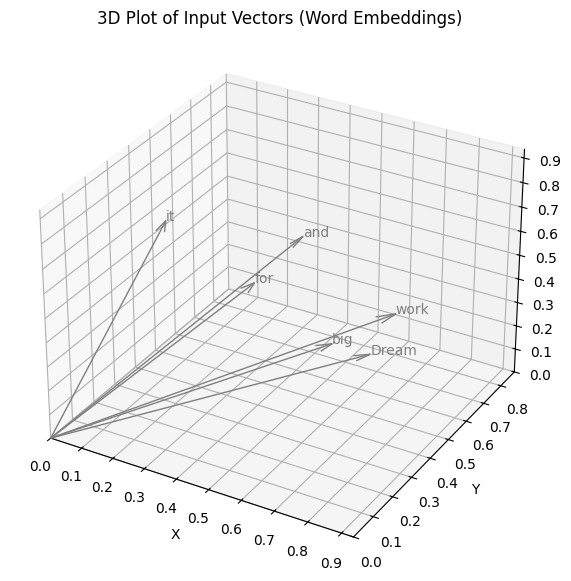

In [5]:
# 3D plot with vectors from origin
colors = ['grey']*6
widths = [1.,1.,1.,1.,1.,1.]
plot_3d_vectors(inputs, words,colors,widths)

## Dot Product Attention for all 6 vectors
Simple Dot product Attention. No Trainable Weights
- X*Xt
- Each row of the output matrix represents the attention scores for the respective word
 
Note 
- X matrix should be such that the different words/ number of samples are along the row. Number of rows = Number of Words = 6
- The embedding dimension should be along the number of columns i.e. Number of columns = Embedding Dimension = 3

### Attention Score matrix
- The 6 rows are the 6 attention scores corresponding to the 6 words against all other words
- the columns have no meaning.
- The attention score matrix is symmetrical. i.e row[0][1] attention of Dream(query) vs big(key) = row[1][0] attention of big(query) vs dream(key)
- Often the attention score of a word against itself can be less than the word against another word. Example row[0][4]: attention of for vs for = 0.8875 < row[0][3] = 0.9700 , attention go for vs work. This can be likely remedied using trainable weight matrices ? . More on that in lect 4p1

##### Query: Dream
- row[0] = [0.8170, 0.8005, 0.7000, 0.9555, 0.6960, 0.5335], is attention score of the query 'Dream'
- row[0][0] is the attention score of query 'Dream' against key 'Dream'
- row[0][1] is the attention score of query 'Dream' against key 'big'
- row[0][2] is the attention score of query 'Dream' against key 'and'
- row[0][3] is the attention score of query 'Dream' against key 'work'
- row[0][4] is the attention score of query 'Dream' against key 'for'
- row[0][5] is the attention score of query 'Dream' against key 'it'

##### Query: big
- row[1] = [0.8005, 0.9050, 0.6050, 1.0375, 0.8550, 0.6950] is the attention score of 'big'. Verify this is the same as the attention scores for the attention score for 'big' in lect3p2_c2_simple_dot_product_attention_for_one_vector.ipynb
- row[1][0] is the attention score of query 'big' against key 'Dream'
- row[1][1] is the attention score of query 'big' against key 'big'
- row[1][2] is the attention score of query 'big' against key 'and'
- row[1][3] is the attention score of query 'big' against key 'work'
- row[1][4] is the attention score of query 'big' against key 'for'
- row[1][5] is the attention score of query 'big' against key 'it'

##### Query: and
- row[2] = [0.7000, 0.6050, 0.8900, 0.7750, 0.5850, 0.5750] is the attention score of 'and' and so and so forth

In [6]:
attention_score_matrix = inputs @ inputs.T
print("attention_score_matrix: \n", attention_score_matrix)

attention_score_matrix: 
 tensor([[0.8170, 0.8005, 0.7000, 0.9555, 0.6960, 0.5335],
        [0.8005, 0.9050, 0.6050, 1.0375, 0.8550, 0.6950],
        [0.7000, 0.6050, 0.8900, 0.7750, 0.5850, 0.5750],
        [0.9555, 1.0375, 0.7750, 1.2050, 0.9700, 0.7925],
        [0.6960, 0.8550, 0.5850, 0.9700, 0.8875, 0.8050],
        [0.5335, 0.6950, 0.5750, 0.7925, 0.8050, 0.8250]])


### Attention Weights
- Normalized Attention Score Matrix. Normalize along the rows, preserving the columns
- Hence the sum of each row adds upto 1
- Due to Normalization the attention score matrix is no longer symmetrical

In [7]:
# dim =1 means preserve the dimension 1 i.e the columns , (normalization is along dimension 0 ,= rows)
attention_weights_matrix = F.softmax(attention_score_matrix, dim =1)
print("attention_weights_matrix: \n", attention_weights_matrix)
# Row-wise sum and variance
row_sum = torch.sum(attention_weights_matrix, dim=1)
row_var = torch.var(attention_weights_matrix, dim=1, unbiased=False)  # use unbiased=False for population variance

print("Row-wise sums:\n", row_sum)
print("Row-wise variances:\n", row_var)

attention_weights_matrix: 
 tensor([[0.1766, 0.1738, 0.1571, 0.2029, 0.1565, 0.1330],
        [0.1624, 0.1803, 0.1336, 0.2059, 0.1715, 0.1462],
        [0.1675, 0.1523, 0.2025, 0.1805, 0.1493, 0.1478],
        [0.1648, 0.1789, 0.1376, 0.2115, 0.1672, 0.1400],
        [0.1491, 0.1747, 0.1334, 0.1960, 0.1805, 0.1662],
        [0.1396, 0.1641, 0.1455, 0.1809, 0.1831, 0.1868]])
Row-wise sums:
 tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000])
Row-wise variances:
 tensor([0.0005, 0.0005, 0.0004, 0.0006, 0.0004, 0.0003])


### Context Vectors

In [8]:
context_vectors = attention_weights_matrix @ inputs
print("context_vectors: \n", context_vectors)

context_vectors: 
 tensor([[0.5965, 0.3611, 0.5654],
        [0.5982, 0.3431, 0.5794],
        [0.5681, 0.3830, 0.5627],
        [0.6008, 0.3471, 0.5758],
        [0.5859, 0.3377, 0.5900],
        [0.5684, 0.3402, 0.5964]])


## Context Vectors Visualization
Apparently the context vectors all look the same after the simple dot product attention in this example. Try using Word 2 vec for the input embeddings to see if anything looks better

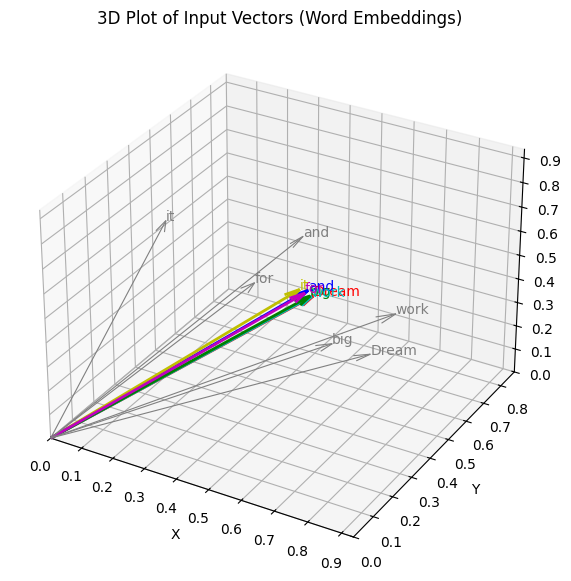

In [9]:
input_vector_colors  = ['grey']*6
context_vector_colors =  ['r', 'g', 'b', 'c', 'm', 'y']

input_vector_widths   = [0.8 * x for x in widths]
context_vector_widths = [2. * x for x in widths]

inp = torch.cat((inputs, context_vectors), dim=0)
wor = words + words 
col = input_vector_colors + context_vector_colors
wid = input_vector_widths + context_vector_widths

plot_3d_vectors(inp, wor,col,wid)